# UX Metrics Processing Notebook

This notebook implements the full metrics process end-to-end, including explicit handling of repeated `tot_ms` entries.

## Important note on "how it was handled before"
In the earlier thesis analysis, repeated `tot_ms` values were aggregated using **mean per participant and `ui_condition`** to produce one ToT value per condition.

In this notebook, Section 3 implements a more generic event-log rule: **sort by timestamp and keep the latest record** for each duplicate key, while also reporting alternate aggregates (`max`, `sum`) for audit.

In [1]:
import pandas as pd # Import pandas untuk manipulasi dan analisis data tabular (DataFrames)
import numpy as np # Import numpy untuk operasi matematika dan array numerik
from pathlib import Path # Import Path untuk manipulasi path file secara aman lintas OS
from scipy import stats # Import scipy.stats untuk uji statistik (Shapiro-Wilk, T-Test, dll)
import matplotlib.pyplot as plt # Import pyplot untuk membuat grafik/plot visual
import seaborn as sns # Import seaborn untuk membuat grafik statistik yang lebih estetis

pd.set_option('display.max_columns', 200) # Atur pandas agar menampilkan maksimal 200 kolom saat diprint
pd.set_option('display.width', 180) # Atur lebar tampilan teks pandas agar tidak terpotong (180 karakter)
sns.set_theme(style='whitegrid') # Atur tema visual seaborn menjadi 'whitegrid' (latar putih dengan grid)

## 1) Load Raw Metrics Files
Load raw metrics from CSV/XLSX, then combine into a single metrics table with source metadata.

In [2]:
# Paths
DATA_DIR = Path('/Users/gvnd/Documents/College/Skripsian/data') # Definisikan folder utama tempat data disimpan
TOT_PATH = DATA_DIR / 'tot_results.csv' # Path file untuk data Time on Task (ToT)
QUESTIONNAIRE_PATH = DATA_DIR / 'Usability Testing Aplikasi Mindscape (Responses) (1).xlsx' # Path file untuk data kuesioner (Excel)

# Raw loads
raw_tot = pd.read_csv(TOT_PATH) # Baca data ToT dari CSV ke dalam DataFrame pandas
raw_quest = pd.read_excel(QUESTIONNAIRE_PATH) # Baca data kuesioner dari Excel ke dalam DataFrame pandas

# Add source metadata for traceability
raw_tot['source_file'] = TOT_PATH.name # Tambahkan kolom nama file asal ke data ToT untuk pelacakan (traceability)
raw_quest['source_file'] = QUESTIONNAIRE_PATH.name # Tambahkan kolom nama file asal ke data kuesioner

print('raw_tot shape:', raw_tot.shape) # Print dimensi (baris, kolom) dari raw_tot
print('raw_quest shape:', raw_quest.shape) # Print dimensi (baris, kolom) dari raw_quest
raw_tot.head() # Tampilkan 5 baris pertama dari data raw_tot

raw_tot shape: (60, 8)
raw_quest shape: (30, 33)


,Nama Tester,ui_condition,tot_ms,mood_logged,logged_at,order,group,source_file
0,Barbara Neanake,standard_ui,14361,happy,2026-03-27 16:26:02,standard_first,A,tot_results.csv
1,Johan,standard_ui,21289,justokay,2026-03-27 16:26:19,standard_first,C,tot_results.csv
2,Barbara Neanake,rush_hour_ui,12710,cheerful,2026-03-27 16:27:13,standard_first,A,tot_results.csv
3,Johan,rush_hour_ui,18619,fine,2026-03-27 16:27:18,standard_first,C,tot_results.csv
4,Dhafarel Hariyanto,rush_hour_ui,9879,gloomy,2026-03-31 17:29:04,rush_first,B,tot_results.csv


## 2) Standardize Schema and Data Types
Normalize names, parse timestamps, cast numeric columns, and enforce required fields.

In [3]:
tot = raw_tot.copy() # Buat salinan data ToT agar raw data tidak terubah
quest = raw_quest.copy() # Buat salinan data kuesioner

# Normalize key names
for df in (tot, quest): # Looping untuk kedua dataframe (tot dan quest)
    if 'Nama Tester' in df.columns: # Jika ada kolom bernama 'Nama Tester'
        df['nama_tester_clean'] = df['Nama Tester'].astype(str).str.strip().str.lower() # Buat kolom baru: ubah ke string, hapus spasi awal/akhir, dan jadikan huruf kecil semua

# Parse and cast
required_tot_cols = ['Nama Tester', 'ui_condition', 'tot_ms', 'logged_at'] # Daftar kolom yang wajib ada di data ToT
missing_tot = [c for c in required_tot_cols if c not in tot.columns] # Cek apakah ada kolom yang hilang
assert not missing_tot, f'Missing required ToT columns: {missing_tot}' # Hentikan program jika ada kolom wajib yang hilang

tot['tot_ms'] = pd.to_numeric(tot['tot_ms'], errors='coerce') # Ubah tipe data tot_ms menjadi numerik, jika error/bukan angka jadikan NaN
tot['tot_sec'] = tot['tot_ms'] / 1000.0 # Buat kolom tot_sec dengan mengonversi milidetik menjadi detik
tot['logged_at'] = pd.to_datetime(tot['logged_at'], errors='coerce') # Ubah teks tanggal di logged_at menjadi tipe data datetime pandas

eri_cols = list(quest.columns[4:12]) # Ambil nama-nama kolom untuk kuesioner ERI (kolom indeks 4 sampai 11)
pei_cols = list(quest.columns[12:20]) # Ambil nama-nama kolom untuk kuesioner PEI (kolom indeks 12 sampai 19)
for c in eri_cols + pei_cols: # Looping semua kolom ERI dan PEI
    quest[c] = pd.to_numeric(quest[c], errors='coerce') # Ubah isian kuesioner menjadi angka (numerik)

quest['ERI_Composite'] = quest[eri_cols].mean(axis=1) # Hitung skor rata-rata (komposit) untuk ERI per baris/responden
quest['PEI_Composite'] = quest[pei_cols].mean(axis=1) # Hitung skor rata-rata (komposit) untuk PEI per baris/responden

# Group mapping
quest['Group'] = quest['Group'].astype(str).str.strip().replace({'nan': pd.NA}) # Bersihkan kolom Group: jadikan string, hapus spasi, ubah 'nan' teks jadi pd.NA (null)
device_map = {'A': 'iPhone 17', 'B': 'iPhone 17', 'C': 'Mi Pad 5', 'D': 'Mi Pad 5'} # Dictionary untuk memetakan kode grup ke jenis perangkat
order_map = {'A': 'Standard First', 'B': 'Rush Hour First', 'C': 'Standard First', 'D': 'Rush Hour First'} # Dictionary pemetaan urutan UI
quest['Device'] = quest['Group'].map(device_map) # Buat kolom 'Device' berdasarkan mapping grup
quest['UI_Order'] = quest['Group'].map(order_map) # Buat kolom 'UI_Order' berdasarkan mapping grup

print('ToT null tot_ms:', tot['tot_ms'].isna().sum()) # Print jumlah data ToT yang bernilai kosong/NaN
print('ToT null logged_at:', tot['logged_at'].isna().sum()) # Print jumlah data waktu yang bernilai kosong/NaN
print('Questionnaire shape:', quest.shape) # Print dimensi data kuesioner setelah diproses

ToT null tot_ms: 0
ToT null logged_at: 0
Questionnaire shape: (30, 38)


## 3) Deduplicate/Resolve Multiple `tot_ms` Entries
Deterministic rule for event-style logs: group by stable keys and keep the latest timestamped record. Also compute duplicate counts and alternate audit aggregates.

For this dataset, stable keys are approximated by:
- `nama_tester_clean`
- `ui_condition`

Because this dataset is per interaction, this strategy selects the latest recorded interaction per participant and UI condition.

Note: Earlier thesis runs used **mean per participant x UI condition**; both outputs are produced below for transparency.

In [4]:
stable_keys = ['nama_tester_clean', 'ui_condition'] # Definisikan kolom kunci untuk mengidentifikasi kombinasi unik user dan kondisi UI

# Duplicate incidence
dup_counts = ( # Mulai rantai operasi pandas
    tot.groupby(stable_keys, dropna=False) # Kelompokkan data ToT berdasarkan user dan kondisi UI
       .size() # Hitung jumlah baris (percobaan) per kelompok
       .rename('n_rows') # Ubah nama hasil hitungan menjadi 'n_rows'
       .reset_index() # Kembalikan index menjadi kolom biasa
)
dup_counts['is_duplicate'] = dup_counts['n_rows'] > 1 # Buat kolom boolean True jika user melakukan percobaan lebih dari sekali di kondisi UI yang sama

# Deterministic latest-record resolution
latest_tot = ( # Mulai rantai operasi pandas
    tot.sort_values('logged_at') # Urutkan seluruh data berdasarkan waktu (dari terlama ke terbaru)
       .groupby(stable_keys, as_index=False) # Kelompokkan berdasarkan user dan kondisi UI
       .tail(1) # Ambil hanya 1 baris terakhir (terbaru) dari setiap kelompok
       .copy() # Buat salinan agar tidak terkait dengan DataFrame asli
)

# Alternate aggregates for audit
audit_aggs = ( # Mulai rantai operasi pandas
    tot.groupby(stable_keys, as_index=False) # Kelompokkan berdasarkan user dan kondisi UI
       .agg( # Lakukan agregasi/perhitungan
           tot_sec_mean=('tot_sec', 'mean'), # Hitung rata-rata waktu (detik)
           tot_sec_max=('tot_sec', 'max'), # Cari waktu terlama (maksimal)
           tot_sec_sum=('tot_sec', 'sum'), # Jumlahkan semua percobaan (total waktu)
           n_records=('tot_sec', 'size'), # Hitung berapa kali percobaan dilakukan
       )
)

# Earlier thesis-compatible aggregation (mean per participant x condition)
mean_tot = ( # Mulai rantai operasi pandas
    tot.groupby(stable_keys, as_index=False) # Kelompokkan berdasarkan user dan kondisi UI
       .agg(tot_sec=('tot_sec', 'mean')) # Hitung rata-rata waktu (pendekatan skripsi lama)
)

print('Total key groups:', len(dup_counts)) # Print total kombinasi (user x UI) yang ada
print('Groups with duplicates:', int(dup_counts['is_duplicate'].sum())) # Print berapa banyak kombinasi yang memiliki duplikat/diulang
display(dup_counts[dup_counts['is_duplicate']].sort_values('n_rows', ascending=False).head(10)) # Tampilkan 10 user dengan percobaan berulang terbanyak
display(audit_aggs.head()) # Tampilkan sebagian data agregasi audit

Total key groups: 60
Groups with duplicates: 0


,nama_tester_clean,ui_condition,n_rows,is_duplicate


,nama_tester_clean,ui_condition,tot_sec_mean,tot_sec_max,tot_sec_sum,n_records
0,adzka bagus juniarta,rush_hour_ui,33.039,33.039,33.039,1
1,adzka bagus juniarta,standard_ui,11.925,11.925,11.925,1
2,alisha,rush_hour_ui,33.214,33.214,33.214,1
3,alisha,standard_ui,5.352,5.352,5.352,1
4,arden,rush_hour_ui,14.086,14.086,14.086,1


## 4) Compute Core Metrics (Latency, Throughput, Error Rate)
Compute per-event latency from resolved `tot_ms`, throughput over fixed time windows, and error rate from status-like fields where available.

In [5]:
# Use latest-record resolved data for generic event-log KPI computation
resolved_events = latest_tot.copy() # Gunakan data 'latest_tot' (percobaan terakhir) sebagai dasar evaluasi metrik
resolved_events['latency_ms'] = resolved_events['tot_ms'] # Salin nilai tot_ms ke kolom standar telemetri: latency_ms
resolved_events['latency_sec'] = resolved_events['tot_sec'] # Salin nilai tot_sec ke kolom standar telemetri: latency_sec

# Throughput per 1-minute window
throughput = ( # Mulai rantai operasi
    resolved_events # Gunakan data event yang sudah direvolve
    .set_index('logged_at') # Jadikan kolom waktu ('logged_at') sebagai index dataframe
    .groupby(pd.Grouper(freq='1min')) # Kelompokkan data per interval 1 menit (time window)
    .size() # Hitung jumlah event/interaksi yang terjadi per menit
    .rename('events_per_min') # Beri nama hasil hitungan sebagai 'events_per_min'
    .reset_index() # Kembalikan index waktu menjadi kolom biasa
)

# Error-rate placeholder: this dataset has no explicit status column.
status_col = None # Inisialisasi variabel untuk mencari kolom status error (jika ada)
for c in ['status', 'result', 'is_error', 'success']: # Loop nama-nama kolom status yang umum
    if c in resolved_events.columns: # Jika kolom tersebut ada di dataset
        status_col = c # Catat nama kolom tersebut
        break # Hentikan pencarian

if status_col is None: # Jika tidak ada kolom indikator error yang ditemukan
    error_rate = np.nan # Set error rate ke NaN (Not a Number/kosong)
    print('No explicit status/result field found; error rate set to NaN for this dataset.') # Print peringatan
else: # Jika kolom error ditemukan
    series = resolved_events[status_col].astype(str).str.lower() # Jadikan seluruh isi kolom jadi huruf kecil string
    error_rate = series.str.contains('error|fail|false').mean() # Hitung proporsi (rata-rata boolean) yang mengandung kata error/gagal

print('Resolved events:', len(resolved_events)) # Print total event yang dianalisis
print('Mean latency (sec):', round(resolved_events['latency_sec'].mean(), 3)) # Print rata-rata waktu (latency)
print('Error rate:', error_rate) # Print nilai error rate
display(throughput.head()) # Tampilkan cuplikan dataframe throughput (event per menit)

No explicit status/result field found; error rate set to NaN for this dataset.
Resolved events: 60
Mean latency (sec): 16.748
Error rate: nan


,logged_at,events_per_min
0,2026-03-27 16:26:00,2
1,2026-03-27 16:27:00,2
2,2026-03-27 16:28:00,0
3,2026-03-27 16:29:00,0
4,2026-03-27 16:30:00,0


## 5) Aggregate by Run, Endpoint, and Time Window
Build grouped summaries with central tendency and percentile statistics for comparison across executions.

This dataset does not include explicit `run_id` or `endpoint`, so those dimensions are proxied by:
- `source_file` as run identifier
- `ui_condition` as endpoint-like category

In [6]:
def p50(x): return np.percentile(x, 50) # Fungsi bantuan untuk menghitung persentil ke-50 (Median)
def p90(x): return np.percentile(x, 90) # Fungsi bantuan untuk menghitung persentil ke-90 (untuk melihat skor lambat/outlier atas)
def p95(x): return np.percentile(x, 95) # Fungsi bantuan untuk menghitung persentil ke-95
def p99(x): return np.percentile(x, 99) # Fungsi bantuan untuk menghitung persentil ke-99

resolved_events['run_id'] = resolved_events['source_file'] # Jadikan nama file sumber sebagai 'run_id' (ID eksekusi)
resolved_events['endpoint'] = resolved_events['ui_condition'] # Gunakan kondisi UI sebagai analogi 'endpoint' (titik tes)
resolved_events['time_bucket_5min'] = resolved_events['logged_at'].dt.floor('5min') # Buat kolom waktu yang dibulatkan ke bawah ke kelipatan 5 menit

agg = ( # Mulai agregasi statistik
    resolved_events # Data yang digunakan
    .groupby(['run_id', 'endpoint', 'time_bucket_5min'], dropna=False) # Kelompokkan berdasarkan run, UI, dan interval 5 menit
    .agg( # Hitung berbagai metrik untuk kolom 'latency_sec' di dalam tiap kelompok
        n=('latency_sec', 'size'), # Hitung jumlah sampel (N)
        mean=('latency_sec', 'mean'), # Hitung rata-rata (Mean)
        p50=('latency_sec', p50), # Hitung Median (P50)
        p90=('latency_sec', p90), # Hitung P90
        p95=('latency_sec', p95), # Hitung P95
        p99=('latency_sec', p99), # Hitung P99
        min=('latency_sec', 'min'), # Hitung nilai terendah (Minimum)
        max=('latency_sec', 'max'), # Hitung nilai tertinggi (Maksimum)
        std=('latency_sec', 'std'), # Hitung simpangan baku (Standard Deviation)
    )
    .reset_index() # Jadikan index kembali menjadi kolom
)

display(agg.head()) # Tampilkan sekilas dataframe agregasi (KPI)

,run_id,endpoint,time_bucket_5min,n,mean,p50,p90,p95,p99,min,max,std
0,tot_results.csv,rush_hour_ui,2026-03-27 16:25:00,2,15.6645,15.6645,18.0281,18.32355,18.55991,12.710,18.619,4.178294
1,tot_results.csv,rush_hour_ui,2026-03-31 17:25:00,2,13.6430,13.6430,16.6542,17.03060,17.33172,9.879,17.407,5.323100
2,tot_results.csv,rush_hour_ui,2026-03-31 17:55:00,1,16.4010,16.4010,16.4010,16.40100,16.40100,16.401,16.401,NaN
3,tot_results.csv,rush_hour_ui,2026-03-31 19:35:00,2,10.0225,10.0225,15.0261,15.65155,16.15191,3.768,16.277,8.845199
4,tot_results.csv,rush_hour_ui,2026-04-01 12:25:00,2,22.9815,22.9815,37.8651,39.72555,41.21391,4.377,41.586,26.310736


## 6) Add Data Quality Checks and Assertions
Validate schema and values: missing keys, negative durations, duplicate-key counts, and outlier detection.

In [7]:
validation = { # Buat dictionary untuk menyimpan hasil pengecekan kualitas data
    'missing_nama_tester': int(tot['nama_tester_clean'].isna().sum()), # Hitung total nama tester yang kosong
    'missing_ui_condition': int(tot['ui_condition'].isna().sum()), # Hitung kondisi UI yang kosong
    'missing_logged_at': int(tot['logged_at'].isna().sum()), # Hitung waktu log yang kosong
    'negative_tot_ms': int((tot['tot_ms'] < 0).sum()), # Hitung jika ada waktu negatif (bug di aplikasi)
    'duplicate_key_groups': int((dup_counts['n_rows'] > 1).sum()), # Hitung jumlah kelompok user x UI yang memiliki duplikat
}

# Outlier rule: above Q3 + 1.5*IQR on resolved latency
q1, q3 = resolved_events['latency_sec'].quantile([0.25, 0.75]) # Cari Kuartil 1 (25%) dan Kuartil 3 (75%)
iqr = q3 - q1 # Hitung Interquartile Range (rentang antar kuartil)
upper_bound = q3 + 1.5 * iqr # Tentukan batas atas outlier menggunakan standar formula statistik (1.5 * IQR)
validation['outlier_count_iqr'] = int((resolved_events['latency_sec'] > upper_bound).sum()) # Hitung berapa banyak data yang melebihi batas atas (outlier)

validation_df = pd.DataFrame({'check': list(validation.keys()), 'value': list(validation.values())}) # Jadikan hasil validasi ke dalam dataframe tabel
display(validation_df) # Tampilkan tabel validasi data

assert validation['negative_tot_ms'] == 0, 'Negative tot_ms detected.' # Hentikan program & error jika ada waktu ToT negatif
assert validation['missing_ui_condition'] == 0, 'Missing ui_condition detected.' # Hentikan program & error jika ada kolom ui_condition yang hilang

,check,value
0,missing_nama_tester,0
1,missing_ui_condition,0
2,missing_logged_at,0
3,negative_tot_ms,0
4,duplicate_key_groups,0
5,outlier_count_iqr,1


## Thesis-Specific Statistical Workflow 
This section reproduces the usability analysis pipeline (descriptive stats, reliability, normality, paired test, correlations, and confound checks) with a configurable ToT resolution strategy.

Set `TOT_STRATEGY` to:
- `"mean"` to replicate prior runs in this chat (mean per participant x UI condition)
- `"latest"` to use latest timestamped record per participant x UI condition
- `"earliest"` to use earliest timestamped record per participant x UI condition (recommended to reduce learning-effect contamination)

In [8]:
TOT_STRATEGY = 'latest'  # Strategi pemilihan ToT. options: 'mean' (rata2), 'latest' (terakhir coba), 'earliest' (pertama coba)

if TOT_STRATEGY == 'mean': # Jika strateginya mean (rata-rata), spt metode skripsi sebelumnya
    tot_for_thesis = (
        tot.groupby(['nama_tester_clean', 'ui_condition'], as_index=False) # Kelompokkan data
           .agg(tot_sec=('tot_sec', 'mean')) # Ambil nilai rata-rata detik per user & kondisi
    )
elif TOT_STRATEGY == 'latest': # Jika strateginya latest (terakhir)
    tot_for_thesis = (
        tot.sort_values('logged_at') # Urut waktu
           .groupby(['nama_tester_clean', 'ui_condition'], as_index=False) # Kelompokkan data
           .tail(1)[['nama_tester_clean', 'ui_condition', 'tot_sec']] # Ambil 1 data terbawah/terakhir (upaya final user)
    )
elif TOT_STRATEGY == 'earliest': # Jika strateginya earliest (pertama)
    tot_for_thesis = (
        tot.sort_values('logged_at') # Urut waktu
           .groupby(['nama_tester_clean', 'ui_condition'], as_index=False) # Kelompokkan data
           .head(1)[['nama_tester_clean', 'ui_condition', 'tot_sec']] # Ambil 1 data teratas/pertama (first attempt)
    )
else: # Jika input string strategi salah
    raise ValueError('TOT_STRATEGY must be mean, latest, or earliest') # Peringatan error

pivot = ( # Mengubah struktur baris menjadi kolom per kondisi UI (pivoting)
    tot_for_thesis.pivot_table(
        index='nama_tester_clean', # Baris diwakilkan oleh nama user
        columns='ui_condition', # Kolom dipecah jadi kondisi UI (Standard & Rush Hour)
        values='tot_sec', # Nilai tabel adalah ToT dalam detik
        aggfunc='mean' # Agregat mean jika secara tak terduga masih ada duplikat
    )
    .reset_index() # Kembalikan nama tester sebagai kolom normal
    .rename(columns={'standard_ui': 'ToT_Standard', 'rush_hour_ui': 'ToT_RushHour'}) # Ubah nama kolom hasil pivot biar lebih gampang dibaca
)

# Persiapan data penggabungan (Merge)
q_keep = quest[['nama_tester_clean', 'Nama Tester', 'Group', 'Device', 'UI_Order', 'ERI_Composite', 'PEI_Composite'] + eri_cols + pei_cols] # Pilih kolom penting dari data kuesioner
merged = pd.merge(q_keep, pivot, on='nama_tester_clean', how='inner') # Gabungkan data kuesioner dengan pivot ToT menggunakan primary key 'nama_tester_clean' (Inner Join)
paired = merged.dropna(subset=['ToT_Standard', 'ToT_RushHour']).copy() # Hapus baris yang datanya bolong (NaN) pada bagian ToT agar sisa yang 'paired' sempurna (mengerjakan keduanya)
paired['ToT_Savings'] = paired['ToT_Standard'] - paired['ToT_RushHour'] # Hitung perbedaan ToT (Penghematan Waktu = ToT Standard dikurang ToT Rush Hour)

print('TOT strategy:', TOT_STRATEGY) # Print strategi apa yang digunakan saat ini
print('N paired:', len(paired)) # Print total sampel data yang paired (lengkap kedua UI)

# Assumption + tests (Asumsi Statistika dan Uji Hipotesis)
def cronbach_alpha(df_items): # Fungsi manual penghitungan Cronbach Alpha untuk reliabilitas kuesioner
    X = df_items.dropna().to_numpy(float) # Bersihkan NaN dan ubah jadi array numerik
    k = X.shape[1] # k = jumlah item kuesioner (kolom)
    return (k / (k - 1)) * (1 - (X.var(axis=0, ddof=1).sum() / X.sum(axis=1).var(ddof=1))) # Formula standar Cronbach Alpha berdasarkan varians

alpha_eri = cronbach_alpha(paired[eri_cols]) # Uji reliabilitas komponen kuesioner ERI
alpha_pei = cronbach_alpha(paired[pei_cols]) # Uji reliabilitas komponen kuesioner PEI
sh_w, sh_p = stats.shapiro(paired['ToT_Savings']) # Uji Normalitas Shapiro-Wilk untuk penghematan waktu (selisih)

if sh_p > 0.05: # Jika p-value Shapiro > 0.05, berarti data terdistribusi normal
    test_name = 'Paired t-test' # Gunakan uji statistik parametrik (Paired T-Test)
    stat, pval = stats.ttest_rel(paired['ToT_Standard'], paired['ToT_RushHour']) # Eksekusi T-Test terkait (sebelum vs sesudah / UI 1 vs UI 2)
    stat_label = 't' # Label statistik hasil adalah 't'
else: # Jika data tidak terdistribusi normal (p <= 0.05)
    test_name = 'Wilcoxon signed-rank' # Gunakan uji statistik non-parametrik (Wilcoxon)
    stat, pval = stats.wilcoxon(paired['ToT_Standard'], paired['ToT_RushHour']) # Eksekusi Wilcoxon test
    stat_label = 'W' # Label statistik hasil adalah 'W'

cohen_dz = paired['ToT_Savings'].mean() / paired['ToT_Savings'].std(ddof=1) # Hitung Effect Size (Cohen's dz) untuk mengukur seberapa besar dampak/ukuran efek Rush Hour

# Correlations (Korelasi)
norm_x = stats.shapiro(paired['ToT_Savings']).pvalue > 0.05 # Uji normalitas X (ToT Savings)
norm_y = stats.shapiro(paired['ERI_Composite']).pvalue > 0.05 # Uji normalitas Y (Skor ERI)
if norm_x and norm_y: # Jika KEDUANYA normal
    c1_method = 'Pearson' # Gunakan uji korelasi Pearson
    c1_r, c1_p = stats.pearsonr(paired['ToT_Savings'], paired['ERI_Composite']) # Hitung nilai r dan p
else: # Jika salah satu TIDAK normal
    c1_method = 'Spearman' # Gunakan uji korelasi Spearman
    c1_r, c1_p = stats.spearmanr(paired['ToT_Savings'], paired['ERI_Composite']) # Hitung nilai korelasi

norm_a = stats.shapiro(paired['ERI_Composite']).pvalue > 0.05
norm_b = stats.shapiro(paired['PEI_Composite']).pvalue > 0.05
if norm_a and norm_b:
    c2_method = 'Pearson'
    c2_r, c2_p = stats.pearsonr(paired['ERI_Composite'], paired['PEI_Composite'])
else:
    c2_method = 'Spearman'
    c2_r, c2_p = stats.spearmanr(paired['ERI_Composite'], paired['PEI_Composite'])

norm_c = stats.shapiro(paired['ToT_Savings']).pvalue > 0.05
norm_d = stats.shapiro(paired['PEI_Composite']).pvalue > 0.05
if norm_c and norm_d:
    c3_method = 'Pearson'
    c3_r, c3_p = stats.pearsonr(paired['ToT_Savings'], paired['PEI_Composite'])
else:
    c3_method = 'Spearman'
    c3_r, c3_p = stats.spearmanr(paired['ToT_Savings'], paired['PEI_Composite'])

# Confounds (Pengecekan Variabel Pengganggu / Confounding Variables)
iphone = paired.loc[paired['Device'] == 'iPhone 17', 'ToT_RushHour'] # Pisahkan ToT untuk user pengguna iPhone 17
mipad = paired.loc[paired['Device'] == 'Mi Pad 5', 'ToT_RushHour'] # Pisahkan ToT untuk user pengguna Mi Pad 5
std_first = paired.loc[paired['UI_Order'] == 'Standard First', 'ToT_RushHour'] # Pisahkan ToT untuk user yang mencoba UI standard dulu (Grup A & C)
rush_first = paired.loc[paired['UI_Order'] == 'Rush Hour First', 'ToT_RushHour'] # Pisahkan ToT untuk user yang mencoba UI rush hour dulu (Grup B & D)

t_dev, p_dev = stats.ttest_ind(iphone, mipad, equal_var=False) # T-Test Independen (Welch): apakah device bikin beda waktu secara signifikan?
t_ord, p_ord = stats.ttest_ind(std_first, rush_first, equal_var=False) # T-Test Independen: apakah urutan mencoba aplikasi bikin beda waktu (learning effect)?

# Pembentukan tabel APA-style (untuk diprint dengan rapi seperti standar laporan ilmiah / skripsi)
# Tabel 1: Deskriptif (Means & SD)
desc = pd.DataFrame([
    ('ToT_Standard (s)', len(paired), paired['ToT_Standard'].mean(), paired['ToT_Standard'].std(ddof=1)),
    ('ToT_RushHour (s)', len(paired), paired['ToT_RushHour'].mean(), paired['ToT_RushHour'].std(ddof=1)),
    ('ERI Composite (1-5)', len(paired), paired['ERI_Composite'].mean(), paired['ERI_Composite'].std(ddof=1)),
    ('PEI Composite (1-5)', len(paired), paired['PEI_Composite'].mean(), paired['PEI_Composite'].std(ddof=1)),
], columns=['Measure', 'N', 'M', 'SD'])

# Tabel 2: Perbandingan Tambahan
tot_pei = pd.DataFrame([
    ('ToT Savings (s)', len(paired), paired['ToT_Savings'].mean(), paired['ToT_Savings'].std(ddof=1)),
    ('PEI Composite (1-5)', len(paired), paired['PEI_Composite'].mean(), paired['PEI_Composite'].std(ddof=1)),
], columns=['Measure', 'N', 'M', 'SD'])

# Tabel 3: Rincian berdasarkan Urutan (Cohort)
order_breakdown = pd.DataFrame([
    ('Standard UI First (Groups A & C)', 'Standard UI (1st trial)', len(paired[paired['UI_Order'] == 'Standard First']), paired.loc[paired['UI_Order'] == 'Standard First', 'ToT_Standard'].mean(), paired.loc[paired['UI_Order'] == 'Standard First', 'ToT_Standard'].std(ddof=1)),
    ('Standard UI First (Groups A & C)', 'Rush Hour UI (2nd trial)', len(paired[paired['UI_Order'] == 'Standard First']), paired.loc[paired['UI_Order'] == 'Standard First', 'ToT_RushHour'].mean(), paired.loc[paired['UI_Order'] == 'Standard First', 'ToT_RushHour'].std(ddof=1)),
    ('Rush Hour UI First (Groups B & D)', 'Rush Hour UI (1st trial)', len(paired[paired['UI_Order'] == 'Rush Hour First']), paired.loc[paired['UI_Order'] == 'Rush Hour First', 'ToT_RushHour'].mean(), paired.loc[paired['UI_Order'] == 'Rush Hour First', 'ToT_RushHour'].std(ddof=1)),
    ('Rush Hour UI First (Groups B & D)', 'Standard UI (2nd trial)', len(paired[paired['UI_Order'] == 'Rush Hour First']), paired.loc[paired['UI_Order'] == 'Rush Hour First', 'ToT_Standard'].mean(), paired.loc[paired['UI_Order'] == 'Rush Hour First', 'ToT_Standard'].std(ddof=1)),
], columns=['Cohort', 'Trial', 'N', 'Mean_ToT_sec', 'SD_ToT_sec'])

# Tabel 4: Asumsi Uji (Reliabilitas dan Normalitas)
assump = pd.DataFrame([
    ('Cronbach alpha ERI (8 items)', alpha_eri, np.nan),
    ('Cronbach alpha PEI (8 items)', alpha_pei, np.nan),
    ('Shapiro-Wilk (ToT difference)', sh_w, sh_p),
], columns=['Test', 'Statistic', 'p'])

# Tabel 5: Hasil Uji Hipotesis Utama
primary = pd.DataFrame([
    (test_name, stat_label, stat, pval, cohen_dz, paired['ToT_Savings'].mean())
], columns=['Test', 'StatLabel', 'Statistic', 'p', "Cohen_dz", 'Mean_ToT_Savings'])

# Tabel 6: Hasil Uji Korelasi
corrs = pd.DataFrame([
    ('ToT Savings vs ERI', c1_method, c1_r, c1_p),
    ('ERI vs PEI', c2_method, c2_r, c2_p),
    ('ToT Savings vs PEI', c3_method, c3_r, c3_p),
], columns=['Variables', 'Method', 'r', 'p'])

# Tabel 7: Pengecekan Variabel Pengganggu
confounds = pd.DataFrame([
    ('Device: iPhone 17 vs Mi Pad 5 (RushHour ToT)', t_dev, p_dev, len(iphone), len(mipad)),
    ('Order: Standard First vs Rush Hour First (RushHour ToT)', t_ord, p_ord, len(std_first), len(rush_first)),
], columns=['Comparison', 't', 'p', 'n_group1', 'n_group2'])

# Print & Display semua tabel secara berurutan
print('\nStep 1: Descriptive Statistics')
display(desc.round(3))
print('\nStep 1b: ToT vs PEI Comparison')
display(tot_pei.round(3))
print('\nStep 1c: ToT by Testing Order')
display(order_breakdown.round(3))
print('\nStep 2: Assumptions')
display(assump.round(4))
print('\nStep 3: paired t test and cohen_dz test for Time on Task Hypothesis Test')
display(primary.round(4))
print('\nStep 4: Correlations')
display(corrs.round(4))
print('\nStep 5: Confound Checks')
display(confounds.round(4))

TOT strategy: latest
N paired: 30

Step 1: Descriptive Statistics


,Measure,N,M,SD
0,ToT_Standard (s),30,14.418,10.041
1,ToT_RushHour (s),30,19.078,14.899
2,ERI Composite (1-5),30,4.296,0.545
3,PEI Composite (1-5),30,4.242,0.462



Step 1b: ToT vs PEI Comparison


,Measure,N,M,SD
0,ToT Savings (s),30,-4.660,16.642
1,PEI Composite (1-5),30,4.242,0.462



Step 1c: ToT by Testing Order


...

,Test,StatLabel,Statistic,p,Cohen_dz,Mean_ToT_Savings
0,Paired t-test,t,-1.5336,0.136,-0.28,-4.6597



Step 4: Correlations


,Variables,Method,r,p
0,ToT Savings vs ERI,Pearson,0.1577,0.4052
1,ERI vs PEI,Pearson,0.8666,0.0000
2,ToT Savings vs PEI,Pearson,0.1041,0.5842



Step 5: Confound Checks


,Comparison,t,p,n_group1,n_group2
0,Device: iPhone 17 vs Mi Pad 5 (RushHour ToT),1.1191,0.2735,16,14
1,Order: Standard First vs Rush Hour First (Rush...,-0.9054,0.3738,15,15


## 7) Visualize Metric Distributions and Trends
Plot latency distribution, trend over time, and duplicate incidence.

/var/folders/w3/ntm35dyj78116x5204z3jpr00000gn/T/ipykernel_68857/2178833621.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resolved_events, x='ui_condition', y='latency_sec', ax=axes[1], palette='Set2') # Grafik 2: Boxplot perbandingan sebaran ToT antara kondisi UI


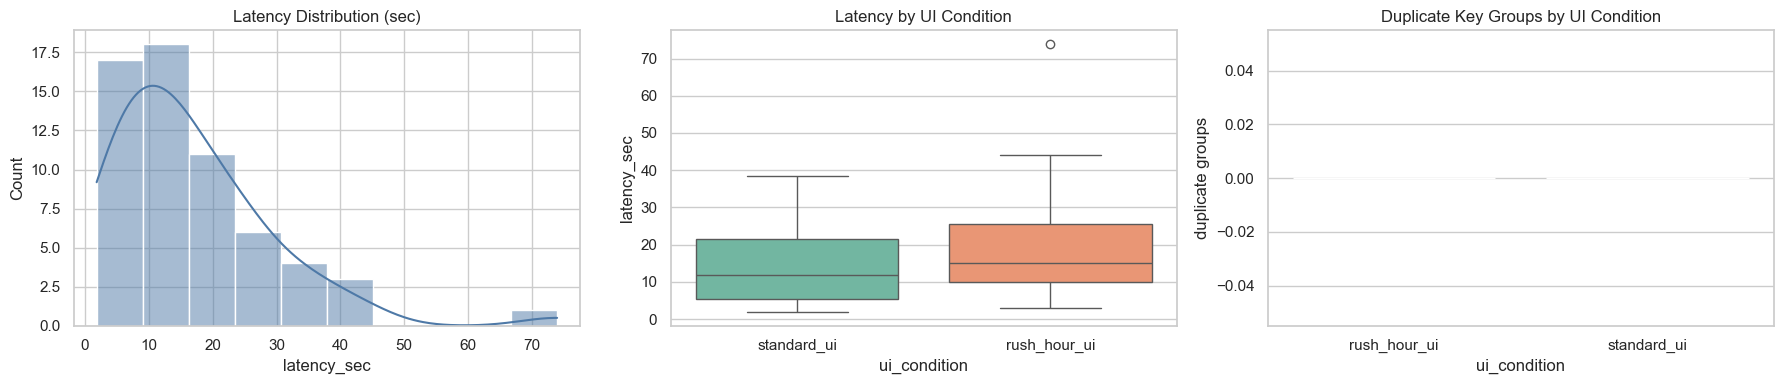

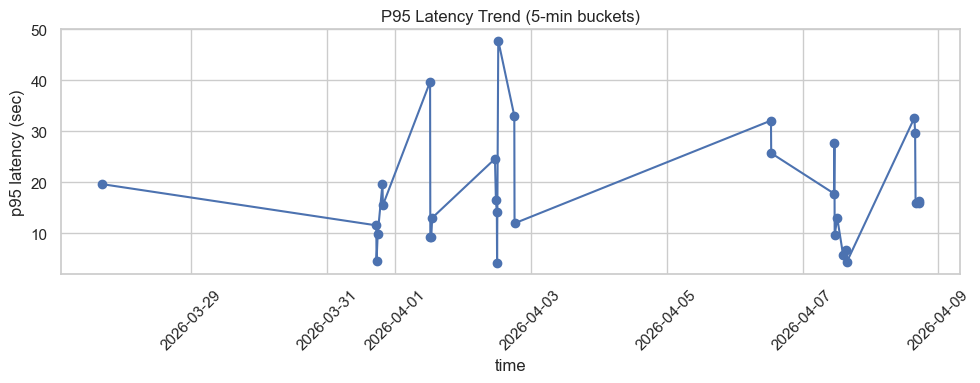

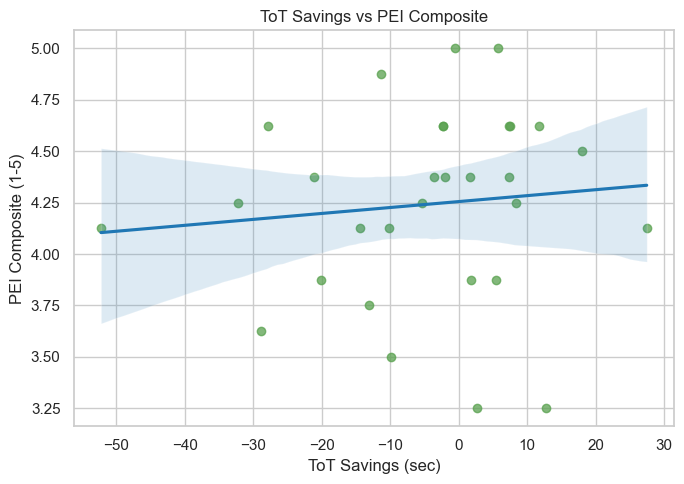

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4)) # Buat canvas plot berisi 1 baris, 3 kolom gambar (lebar 18, tinggi 4)

sns.histplot(resolved_events['latency_sec'], kde=True, ax=axes[0], color='#4e79a7') # Grafik 1: Histogram distribusi waktu latensi/ToT beserta kurva kepadatannya
axes[0].set_title('Latency Distribution (sec)') # Judul Grafik 1

sns.boxplot(data=resolved_events, x='ui_condition', y='latency_sec', ax=axes[1], palette='Set2') # Grafik 2: Boxplot perbandingan sebaran ToT antara kondisi UI
axes[1].set_title('Latency by UI Condition') # Judul Grafik 2
axes[1].set_xlabel('ui_condition') # Label sumbu X Grafik 2

dup_per_ui = dup_counts.groupby('ui_condition', as_index=False)['is_duplicate'].sum() # Hitung jumlah duplikat (re-attempt) per masing-masing kondisi UI
sns.barplot(data=dup_per_ui, x='ui_condition', y='is_duplicate', ax=axes[2], color='#f28e2b') # Grafik 3: Barchart jumlah duplikat per UI (untuk melihat UI mana yang lebih sering bikin user bingung)
axes[2].set_title('Duplicate Key Groups by UI Condition') # Judul Grafik 3
axes[2].set_ylabel('duplicate groups') # Label sumbu Y Grafik 3

plt.tight_layout() # Rapikan layout plot agar tidak tumpang tindih
plt.show() # Tampilkan 3 grafik pertama

trend = agg.groupby('time_bucket_5min', as_index=False)['p95'].mean() # Rata-ratakan skor P95 (persentil atas) berdasarkan time window 5 menit
plt.figure(figsize=(10, 4)) # Buat grafik baru ukuran 10x4
plt.plot(trend['time_bucket_5min'], trend['p95'], marker='o') # Plot garis tren waktu terhadap latensi P95
plt.title('P95 Latency Trend (5-min buckets)') # Judul plot tren
plt.xlabel('time') # Sumbu X
plt.ylabel('p95 latency (sec)') # Sumbu Y
plt.xticks(rotation=45) # Putar tulisan waktu X-axis 45 derajat agar terbaca
plt.tight_layout() # Rapikan layout
plt.show() # Tampilkan plot tren

plt.figure(figsize=(7, 5)) # Buat grafik baru ukuran 7x5 untuk korelasi
sns.regplot( # Buat Scatter Plot sekaligus regresi linier (garis tren)
    data=paired, # Data yang dipakai adalah 'paired' (perbandingan Rush Hour vs Standard)
    x='ToT_Savings', # Sumbu X: Waktu yang dihemat (Standard - Rush Hour)
    y='PEI_Composite', # Sumbu Y: Skor PEI (Perceived Efficiency)
    scatter_kws={'alpha': 0.75, 'color': '#59a14f'}, # Format warna & transparansi titik (hijau)
    line_kws={'color': '#1f77b4'} # Format warna garis tren (biru)
)
plt.title('ToT Savings vs PEI Composite') # Judul plot regresi
plt.xlabel('ToT Savings (sec)') # Sumbu X
plt.ylabel('PEI Composite (1-5)') # Sumbu Y
plt.tight_layout() # Rapikan layout
plt.show() # Tampilkan plot korelasi

## 8) Export Clean Metrics and Summary Tables
Write resolved event-level data, KPI aggregates, and validation report for downstream reuse.

In [10]:
OUT_DIR = Path('analysis_outputs') # Tentukan folder output dengan nama 'analysis_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True) # Buat folder tersebut jika belum ada di sistem

resolved_events.to_csv(OUT_DIR / 'resolved_events_latest.csv', index=False) # Export data event yang sudah direvolve (latest) menjadi file CSV (tanpa kolom index)
audit_aggs.to_csv(OUT_DIR / 'tot_duplicate_audit.csv', index=False) # Export data rekapitulasi audit duplikat ke CSV
agg.to_csv(OUT_DIR / 'kpi_aggregates.csv', index=False) # Export metrik agregasi per time bucket (p50, p90, dll) ke CSV
validation_df.to_csv(OUT_DIR / 'validation_report.csv', index=False) # Export hasil laporan kualitas dan validasi data ke CSV

print('Exported files:') # Print pemberitahuan
for p in sorted(OUT_DIR.glob('*')): # Loop setiap file yang ada di folder output secara urut alfabet
    print('-', p) # Print path file yang baru saja diexport

Exported files:
- analysis_outputs/combined_participant_metrics.xlsx
- analysis_outputs/combined_participant_metrics_final.xlsx
- analysis_outputs/combined_participant_metrics_final_v2.xlsx
- analysis_outputs/combined_participant_metrics_final_v3.xlsx
- analysis_outputs/combined_participant_metrics_final_v4.xlsx
- analysis_outputs/combined_participant_metrics_mapped.xlsx
- analysis_outputs/kpi_aggregates.csv
- analysis_outputs/name_fuzzy_matches.csv
- analysis_outputs/resolved_events_latest.csv
- analysis_outputs/statistical_report.md
- analysis_outputs/tot_duplicate_audit.csv
- analysis_outputs/validation_report.csv


## H2: One-Sampled T-Test


In [11]:
# H2: One-Sample Test for ERI and PEI against a reference value of 3.0
import numpy as np
import pandas as pd
from scipy import stats

reference_value = 3.0
h2_results = []

for var_name in ['ERI_Composite', 'PEI_Composite']:
    scores = paired[var_name].dropna()
    n = len(scores)
    mean_score = scores.mean()
    sd_score = scores.std(ddof=1)
    
    # 1. Shapiro-Wilk for normality
    sh_w, sh_p = stats.shapiro(scores)
    
    # 2. Choose test based on normality
    if sh_p > 0.05:
        test_type = "One-sample t-test (two-tailed)"
        stat, pval = stats.ttest_1samp(scores, popmean=reference_value)
        stat_label = "t"
    else:
        test_type = "Wilcoxon signed-rank test (two-tailed)"
        # Wilcoxon signed-rank against a reference value
        stat, pval = stats.wilcoxon(scores - reference_value)
        stat_label = "W"
        
    # 3. Effect size (Cohen's d for one sample)
    cohens_d = (mean_score - reference_value) / sd_score
    
    h2_results.append({
        "Variable": var_name,
        "N": n,
        "Mean": mean_score,
        "SD": sd_score,
        "Test": test_type,
        "Statistic_Label": stat_label,
        "Statistic": stat,
        "df": n - 1 if stat_label == "t" else "-",
        "p-value": pval,
        "Cohen's d": cohens_d,
        "Normality (Shapiro p)": sh_p
    })

h2_df = pd.DataFrame(h2_results)

print("H2: One-Sample Test Results (ERI and PEI against 3.0)")
display(h2_df.round(4))

# Generate text summary for Table 4.3 / the text
for res in h2_results:
    p_str = "< 0.001" if res["p-value"] < 0.001 else f"= {res['p-value']:.3f}"
    stat_val = f"{res['Statistic']:.3f}"
    stat_text = f"{res['Statistic_Label']}({res['df']}) = {stat_val}" if res['Statistic_Label'] == 't' else f"{res['Statistic_Label']} = {stat_val}"
    
    print(f"\nReport for {res['Variable']}:")
    print(f"{res['Variable'].split('_')[0]} scores (M = {res['Mean']:.3f}, SD = {res['SD']:.3f}) were significantly above the scale midpoint, "
          f"{stat_text}, p {p_str}, d = {res['Cohen\'s d']:.3f}, supporting H2.")


H2: One-Sample Test Results (ERI and PEI against 3.0)


,Variable,N,Mean,SD,Test,Statistic_Label,Statistic,df,p-value,Cohen's d,Normality (Shapiro p)
0,ERI_Composite,30,4.2958,0.5448,One-sample t-test (two-tailed),t,13.0268,29,0.0,2.3783,0.1214
1,PEI_Composite,30,4.2417,0.4618,One-sample t-test (two-tailed),t,14.7258,29,0.0,2.6886,0.2044



Report for ERI_Composite:
ERI scores (M = 4.296, SD = 0.545) were significantly above the scale midpoint, t(29) = 13.027, p < 0.001, d = 2.378, supporting H2.

Report for PEI_Composite:
PEI scores (M = 4.242, SD = 0.462) were significantly above the scale midpoint, t(29) = 14.726, p < 0.001, d = 2.689, supporting H2.
